In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm

from response_stats.pipeline import SimulationConfig, ResponseSimulator, _force_matlab_cell_structure, _parse_save_by_language, _as_cell_of_scalars, _as_numeric_vector, _is_sequence, _as_cell_of_vectors
from response_stats.generators import PoissonSpikeGenerator

from response_stats.plot_utils import *

from scipy.ndimage import gaussian_filter

In [2]:
baseline_frs = np.arange(0.1, 15.1, 0.2)
response_frs = np.arange(0.1, 50, 0.2)

fr_pairs = np.array([[b, r] for b in baseline_frs for r in response_frs])
n_samples = len(fr_pairs)
print(f"# samples: {n_samples}")

fr_baseline = fr_pairs[:,0]
fr_response = fr_pairs[:,1]

burst_rate_baseline_all = np.ones(n_samples) * 0.5
burst_rate_response_all = np.ones(n_samples) * 15

save_dir = Path("/media/al/darch/response_stats/datasets/uniform_sampling_incl_negative_bursts")

# samples: 18750


### check

In [57]:
def check_burst_dfs(save_path,):
    f = list(save_path.glob("*.parquet"))[0]
    df = pd.read_parquet(f)

    bin_size = 25 / 1000
    sigma = 1

    baseline_T = 2
    stimulus_T = 2

    measured_response_peak = []
    measured_response_mean = []
    measured_baseline_mean = []

    for i, row in df.iterrows():
        trial_activity = row.rasters

        bins = np.arange(baseline_T * -1, stimulus_T + (bin_size), bin_size)
        bin_centers = np.convolve(bins, np.ones(2) / 2, mode="valid")
        binned_spikes = np.array([np.histogram(e, bins=bins)[0] for e in trial_activity]) / bin_size
        mean_fr = np.mean(binned_spikes, axis=0)
        smooth_fr = np.mean(gaussian_filter(binned_spikes, sigma=sigma), axis=0)

        mean_fr_baseline = mean_fr[(bin_centers < 0) ]

        if row.fr_baseline > row.fr_response:
            # mean response period is latency + duration
            # peak is the minimum
            mean_fr_response = mean_fr[(bin_centers > row.latency) & (bin_centers < (row.latency + row.duration))]
            peak = np.min(mean_fr_response)
        elif np.isclose(row.fr_response, row.fr_baseline, atol=2):
            # mean response period is the entire response section, to match the baseline period
            # peak is the average
            mean_fr_response = mean_fr[(bin_centers > 0) & (bin_centers < 2)]
            peak = np.mean(mean_fr_response)
        else:
            # mean response period is latency + duration
            # peak is the max during this section
            mean_fr_response = mean_fr[(bin_centers > row.latency) & (bin_centers < (row.latency + row.duration))]
            peak = np.max(mean_fr_response)

        measured_response_peak.append(peak)
        measured_response_mean.append(np.mean(mean_fr_response))
        measured_baseline_mean.append(np.mean(mean_fr_baseline))

    df["measured_response_peak"] = measured_response_peak
    df["measured_response_mean"] = measured_response_mean
    df["measured_baseline_mean"] = measured_baseline_mean

    df.to_parquet(save_path / f"{f.stem}_measured_FRs.parquet")
    return df

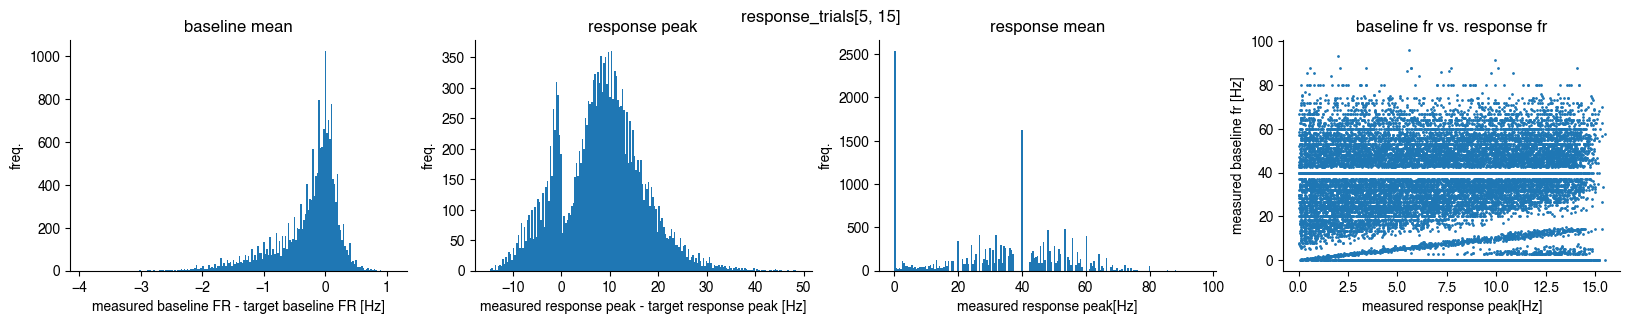

In [61]:
#trial_set = "[100, 500]"
#trial_set = "[15, 100]"
trial_set = "[5, 15]"


save_path = (save_dir / f"response_trials{trial_set}")
df = check_burst_dfs(save_path)

fig, axes = plt.subplots(1,4, figsize=(20,3))
ax = axes[0]
ax.hist(df["measured_baseline_mean"] - df["fr_baseline"], bins=200)
ax.set_title("baseline mean")
ax.set_ylabel("freq.")
ax.set_xlabel("measured baseline FR - target baseline FR [Hz]")

ax = axes[1]
ax.hist(df["measured_response_peak"] - df["fr_response"], bins=200)
ax.set_title("response peak")
ax.set_ylabel("freq.")
ax.set_xlabel("measured response peak - target response peak [Hz]")

ax = axes[2]
ax.hist(df["measured_response_peak"], bins=200)
ax.set_title("response mean")
ax.set_ylabel("freq.")
ax.set_xlabel("measured response peak[Hz]")

ax = axes[3]
ax.scatter(df["measured_baseline_mean"], df["measured_response_peak"], s=1, )
ax.set_title("baseline fr vs. response fr")
ax.set_ylabel("measured baseline fr [Hz]")
ax.set_xlabel("measured response peak[Hz]")

fig.suptitle(f"response_trials{trial_set}\n\n",)

sns.despine()
plt.savefig(save_path / "measured_vs_target_FRs.png")
